# Ускорение инференса UNet модели

## План работы

1. Получение PyTorch baseline fp16 для экспериментов
   * Подготовка данных для обучения модели
   * Формирование модели и train-loop
   * Обучение модели
   * Сохранение модели
   * Получение метрик baseline
2. Проведение экспериментов
   * PyTorch torch.compile
   * Альтернативный компилятор, например TVM (Relax/TIR)
   * Квантизация
   * Спарсификация: pruning / 2:4 semi-structured
3. Итоговый анализ
   * Сравнительная таблица по времени
   * Замер времени после улучшений и сравнение с бейзлайнами + контроль качества/ошибки относительно FP16-референса.
   * Подробное описание ускорений
   * Выводы


**В данном файле представлен только первый пункт работ**

## 1. Получение PyTorch baseline fp16 для экспериментов

В качестве baseline будем использовать UNet модель из smp с предобученным енкодером на ImageNet и дообученной на датасете COCO.

А для эталлоных решений будем использовать изображения и маски, которые будут получены для изображений ImageNet с соответствующими классами

### 1.1 Подготовка данных для обучения модели

Для обучения будем использовать датасет COCO

In [24]:
import numpy as np
import torch
from pycocotools.coco import COCO
from torch.utils.data import DataLoader, Dataset

import segmentation_models_pytorch as smp

from torchvision.transforms import v2 as tr
from torchvision import tv_tensors

import random
import matplotlib.pyplot as plt

import os
from pathlib import Path
import zipfile
from urllib.request import urlretrieve

import time
import copy
import torch.nn as nn

from PIL import Image as PILImage

from IPython.display import clear_output

from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch

from termcolor import colored
from collections import defaultdict

from tqdm.auto import tqdm
import heapq

import colorsys
from torchvision.transforms import InterpolationMode
from torchvision.transforms.functional import pil_to_tensor

Определим константы

In [ ]:
IGNORE_INDEX = 255
NUM_WORKERS = 4
BATCH_SIZE = 16
IMAGE_SIZE = (384, 384)

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
NUM_CLASSES = 81
LR = 1e-3
WEIGHT_DECAY = 1e-4
EPOCHS = 20
WARM_EPOCHS = 6

# Установить True, если нужна точная воспроизводимость. Замедляет обучение!
FIX_SEED = False
SEED = 42

# TODO Понять как влияет на обучение и не мешает ли экспериментам.
USE_AMP = torch.cuda.is_available()

ROOT_DATASET = "/data/datasets/coco"
CKPT_DIR = "./weights/"
CKPT_TOPK_DIR = CKPT_DIR + "topk"

Обеспечим воспроизводимость


In [26]:
def seed_everything(seed: int):
    os.environ["PYTHONHASHSEED"] = str(seed)

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True, warn_only=True)

def seed_worker(_worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

if FIX_SEED:
    seed_everything(SEED)
    seed_generator = torch.Generator()
    seed_generator.manual_seed(SEED)
else:
    seed_generator=None
    seed_worker = None


Скачаем датасет и сформируем файлы масок

In [27]:
# import os
# import zipfile
# from pathlib import Path
# from urllib.request import urlretrieve

# ROOT = Path(ROOT_DATASET)
# ROOT.mkdir(parents=True, exist_ok=True)

# urls = {
#     "train2017.zip": "http://images.cocodataset.org/zips/train2017.zip",
#     "val2017.zip": "http://images.cocodataset.org/zips/val2017.zip",
#     "annotations_trainval2017.zip": "http://images.cocodataset.org/annotations/annotations_trainval2017.zip",
# }

# def download(url, dst):
#     if dst.exists():
#         print(f"[skip] {dst.name} already exists")
#         return
#     print(f"[download] {dst.name}")
#     urlretrieve(url, dst)
#     print(f"[ok] {dst.name}")

# def extract(zip_path, out_dir):
#     marker = out_dir / (zip_path.stem.replace(".zip", ""))
#     print(f"[extract] {zip_path.name}")
#     with zipfile.ZipFile(zip_path, "r") as zf:
#         zf.extractall(out_dir)
#     print(f"[ok] extracted {zip_path.name}")

# for name, url in urls.items():
#     zip_path = ROOT / name
#     download(url, zip_path)
#     extract(zip_path, ROOT)

# print("Done. Check structure:")
# for p in [
#     ROOT / "train2017",
#     ROOT / "val2017",
#     ROOT / "annotations" / "instances_train2017.json",
#     ROOT / "annotations" / "instances_val2017.json",
# ]:
#     print(p, "->", p.exists())

# print(train_ds.num_classes)
# print(train_ds.class_names[:10])
# print(train_ds.class_names)

In [28]:
# def build_coco_semantic_masks(
#     root=ROOT_DATASET,
#     split="train2017",
#     out_dir_name="semantic_masks",
#     ignore_index=IGNORE_INDEX,
#     skip_crowd=True,
# ):
#     """
#     Создает PNG-маски semantic segmentation для COCO split.
#     Маска: 0=background, 1..80=классы COCO (плотная перенумерация), 255=ignore (crowd).
#     """
#     root = Path(root)
#     ann_file = root / "annotations" / f"instances_{split}.json"
#     images_dir = root / split
#     masks_dir = root / out_dir_name / split
#     masks_dir.mkdir(parents=True, exist_ok=True)

#     coco = COCO(str(ann_file))
#     image_ids = sorted(coco.getImgIds())

#     # cat_id -> train_id (1..N), 0 оставляем background
#     cat_ids = sorted(coco.getCatIds())
#     cat_id_to_train_id = {cat_id: i + 1 for i, cat_id in enumerate(cat_ids)}

#     # сохранить mapping для повторного использования
#     mapping_path = root / out_dir_name / "cat_id_to_train_id.npy"
#     np.save(mapping_path, cat_id_to_train_id, allow_pickle=True)

#     for image_id in tqdm(image_ids, desc=f"Building masks {split}"):
#         img_info = coco.loadImgs(image_id)[0]
#         h, w = img_info["height"], img_info["width"]
#         out_path = masks_dir / (Path(img_info["file_name"]).stem + ".png")

#         # если маска уже есть, можно пропустить
#         if out_path.exists():
#             continue

#         mask = np.zeros((h, w), dtype=np.uint8)

#         ann_ids = coco.getAnnIds(imgIds=image_id, iscrowd=None)
#         anns = coco.loadAnns(ann_ids)
#         anns = sorted(anns, key=lambda a: a.get("area", 0), reverse=True)

#         for ann in anns:
#             m = coco.annToMask(ann).astype(bool)

#             if ann.get("iscrowd", 0) == 1:
#                 if skip_crowd:
#                     mask[m] = ignore_index
#                 continue

#             train_id = cat_id_to_train_id[ann["category_id"]]  # 1..80
#             mask[m] = train_id

#         PILImage.fromarray(mask, mode="L").save(out_path)

#     print(f"[OK] {split}: masks in {masks_dir}")


# # Запуск (один раз):
# # build_coco_semantic_masks(root=ROOT_DATASET, split="train2017")
# # build_coco_semantic_masks(root=ROOT_DATASET, split="val2017")

Формирование даталоадеров

In [29]:
class SegTransform:
    '''
    Класс-преобразователь, который применяет аугментации к паре (image, mask)
    '''
    
    def __init__(self, size, train=True):

        self.mean = IMAGENET_MEAN
        self.std = IMAGENET_STD

        if train:
            self.joint_prepare = tr.Compose([
                tr.RandomResizedCrop(
                    size,
                    scale=(0.6, 1.0),
                    interpolation=InterpolationMode.BILINEAR,
                    antialias=True
                ),
                tr.RandomHorizontalFlip(p=0.5),
            ])
        else:
            self.joint_prepare = tr.Compose([
                tr.Resize(size, interpolation=InterpolationMode.BILINEAR, antialias=True),
            ])

        if train:
            self.image_prepare = tr.Compose([
                tr.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.02),
                tr.ToDtype(torch.float32, scale=True),
                tr.Normalize(mean=self.mean, std=self.std),
            ])
        else:
            self.image_prepare = tr.Compose([
                tr.ToDtype(torch.float32, scale=True),
                tr.Normalize(mean=self.mean, std=self.std),
            ])

    def __call__(self, image, mask):
        image = tv_tensors.Image(image)
        mask = tv_tensors.Mask(pil_to_tensor(mask).squeeze(0).to(torch.int64))  # без np.array

        image, mask = self.joint_prepare(image, mask)
        image = self.image_prepare(image)
        return image, mask.long()

In [30]:
def seg_collate_fn(batch):
    images, masks = zip(*batch)
    images = torch.stack(images, dim=0)
    masks = torch.stack(masks, dim=0)
    return images, masks

In [31]:
class COCOSemanticDataset(Dataset):
    """
    Semantic-seg dataset на базе COCO instances.
    Возвращает:
      image: PIL.Image (RGB)
      mask:  PIL.Image (L), где:
             0 = background
             1..N = категории COCO (плотная перенумерация)
             ignore_index (по умолчанию 255) можно использовать при необходимости
    """

    def __init__(
        self,
        root=ROOT_DATASET,
        split="train2017",
        masks_root="semantic_masks",
        ann_file=None,
        transforms=None,
        ignore_index=IGNORE_INDEX,
    ):
        self.root = Path(root)
        self.split = split
        self.transforms = transforms
        self.ignore_index = ignore_index

        self.images_dir = self.root / split
        self.masks_dir = self.root / masks_root / split

        if ann_file is None:
            ann_file = self.root / "annotations" / f"instances_{split}.json"
        self.coco = COCO(str(ann_file))

        self.image_ids = sorted(self.coco.getImgIds())

        cat_ids = sorted(self.coco.getCatIds())
        cats = self.coco.loadCats(cat_ids)
        self.class_names = ["background"] + [c["name"] for c in sorted(cats, key=lambda x: x["id"])]
        self.num_classes = len(self.class_names)

        # Проверка наличия масок
        missing = 0
        for image_id in self.image_ids[:500]:  # быстрая проверка части
            info = self.coco.loadImgs(image_id)[0]
            mpath = self.masks_dir / (Path(info["file_name"]).stem + ".png")
            if not mpath.exists():
                missing += 1
        if missing > 0:
            raise FileNotFoundError(
                f"Missing precomputed masks in {self.masks_dir}. "
                f"Run build_coco_semantic_masks(...) first."
            )

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        image_id = self.image_ids[idx]
        info = self.coco.loadImgs(image_id)[0]

        image_path = self.images_dir / info["file_name"]
        mask_path = self.masks_dir / (Path(info["file_name"]).stem + ".png")

        with PILImage.open(image_path) as im:
            image = im.convert("RGB").copy()

        with PILImage.open(mask_path) as mm:
            mask = mm.convert("L").copy()

        if self.transforms is not None:
            image, mask = self.transforms(image, mask)

        return image, mask

In [32]:
train_ds = COCOSemanticDataset(
    root=ROOT_DATASET,
    split="train2017",
    masks_root="semantic_masks",
    transforms=SegTransform(size=IMAGE_SIZE, train=True),
)

val_ds = COCOSemanticDataset(
    root=ROOT_DATASET,
    split="val2017",
    masks_root="semantic_masks",
    transforms=SegTransform(size=IMAGE_SIZE, train=False),
)

loading annotations into memory...
Done (t=4.35s)
creating index...
index created!
loading annotations into memory...
Done (t=0.20s)
creating index...
index created!


In [33]:
train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=False,
    prefetch_factor=2,
    collate_fn=seg_collate_fn,
    worker_init_fn=seed_worker,
    generator=seed_generator,
    timeout= 60,
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=False,
    prefetch_factor=2,
    collate_fn=seg_collate_fn,
    worker_init_fn=seed_worker,
    generator=seed_generator,
    timeout= 60,
)

Изобразим несколько пар изображений на выходе из лоадеров

In [34]:
def _denorm(img: torch.Tensor) -> np.ndarray:
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    x = (img.detach().cpu() * std) + mean
    x = x.clamp(0, 1).permute(1, 2, 0).numpy()
    return x

def _build_seg_cmap_with_ignore(num_classes: int, ignore_color=(0.15, 0.15, 0.15, 1.0)):
    hues = (np.arange(num_classes) * 0.61803398875) % 1.0
    colors = []
    for h in hues:
        r, g, b = colorsys.hsv_to_rgb(h, 0.75, 1.0)
        colors.append((r, g, b, 1.0))

    colors.append(ignore_color)
    cmap = ListedColormap(colors)
    norm = BoundaryNorm(np.arange(-0.5, num_classes + 1.5, 1), cmap.N)
    return cmap, norm

def _mask_boundaries(m: np.ndarray) -> np.ndarray:
    b = np.zeros_like(m, dtype=bool)
    b[:-1, :] |= (m[:-1, :] != m[1:, :])
    b[:, :-1] |= (m[:, :-1] != m[:, 1:])
    return b

def _boundary_rgba(mask: np.ndarray, color=(1.0, 1.0, 1.0, 1.0)):
    bd = _mask_boundaries(mask)
    overlay = np.zeros((*bd.shape, 4), dtype=np.float32)
    overlay[bd] = color
    return overlay

def _mask_for_show(mask: torch.Tensor, ignore_index: int, ignore_show_id: int) -> np.ndarray:
    m = mask.detach().cpu().numpy().copy()
    m[m == ignore_index] = ignore_show_id
    return m

In [35]:
def show_train_val_pairs(train_ds, val_ds, n_pairs: int, seed: int, ignore_index: int):
    """
    Показывает n_pairs примеров из train и val:
    [train image | train mask | val image | val mask]
    """
    rng = random.Random(seed)
    train_ids = [rng.randrange(len(train_ds)) for _ in range(n_pairs)]
    val_ids = [rng.randrange(len(val_ds)) for _ in range(n_pairs)]

    num_classes = train_ds.num_classes
    ignore_show_id = num_classes
    cmap, norm = _build_seg_cmap_with_ignore(num_classes)

    fig, axes = plt.subplots(n_pairs, 4, figsize=(14, 3.5 * n_pairs))
    if n_pairs == 1:
        axes = np.expand_dims(axes, axis=0)

    for i in range(n_pairs):
        tr_img, tr_mask = train_ds[train_ids[i]]
        va_img, va_mask = val_ds[val_ids[i]]

        tr_show = _mask_for_show(tr_mask, ignore_index, ignore_show_id)
        va_show = _mask_for_show(va_mask, ignore_index, ignore_show_id)

        axes[i, 0].imshow(_denorm(tr_img))
        axes[i, 0].set_title(f"Train image #{train_ids[i]}")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(tr_show, cmap=cmap, norm=norm, interpolation="nearest")
        axes[i, 1].imshow(_boundary_rgba(tr_show), interpolation="nearest")
        axes[i, 1].set_title("Train mask")
        axes[i, 1].axis("off")

        axes[i, 2].imshow(_denorm(va_img))
        axes[i, 2].set_title(f"Val image #{val_ids[i]}")
        axes[i, 2].axis("off")

        axes[i, 3].imshow(va_show, cmap=cmap, norm=norm, interpolation="nearest")
        axes[i, 3].imshow(_boundary_rgba(va_show), interpolation="nearest")
        axes[i, 3].set_title("Val mask")
        axes[i, 3].axis("off")

    plt.tight_layout()
    plt.show()

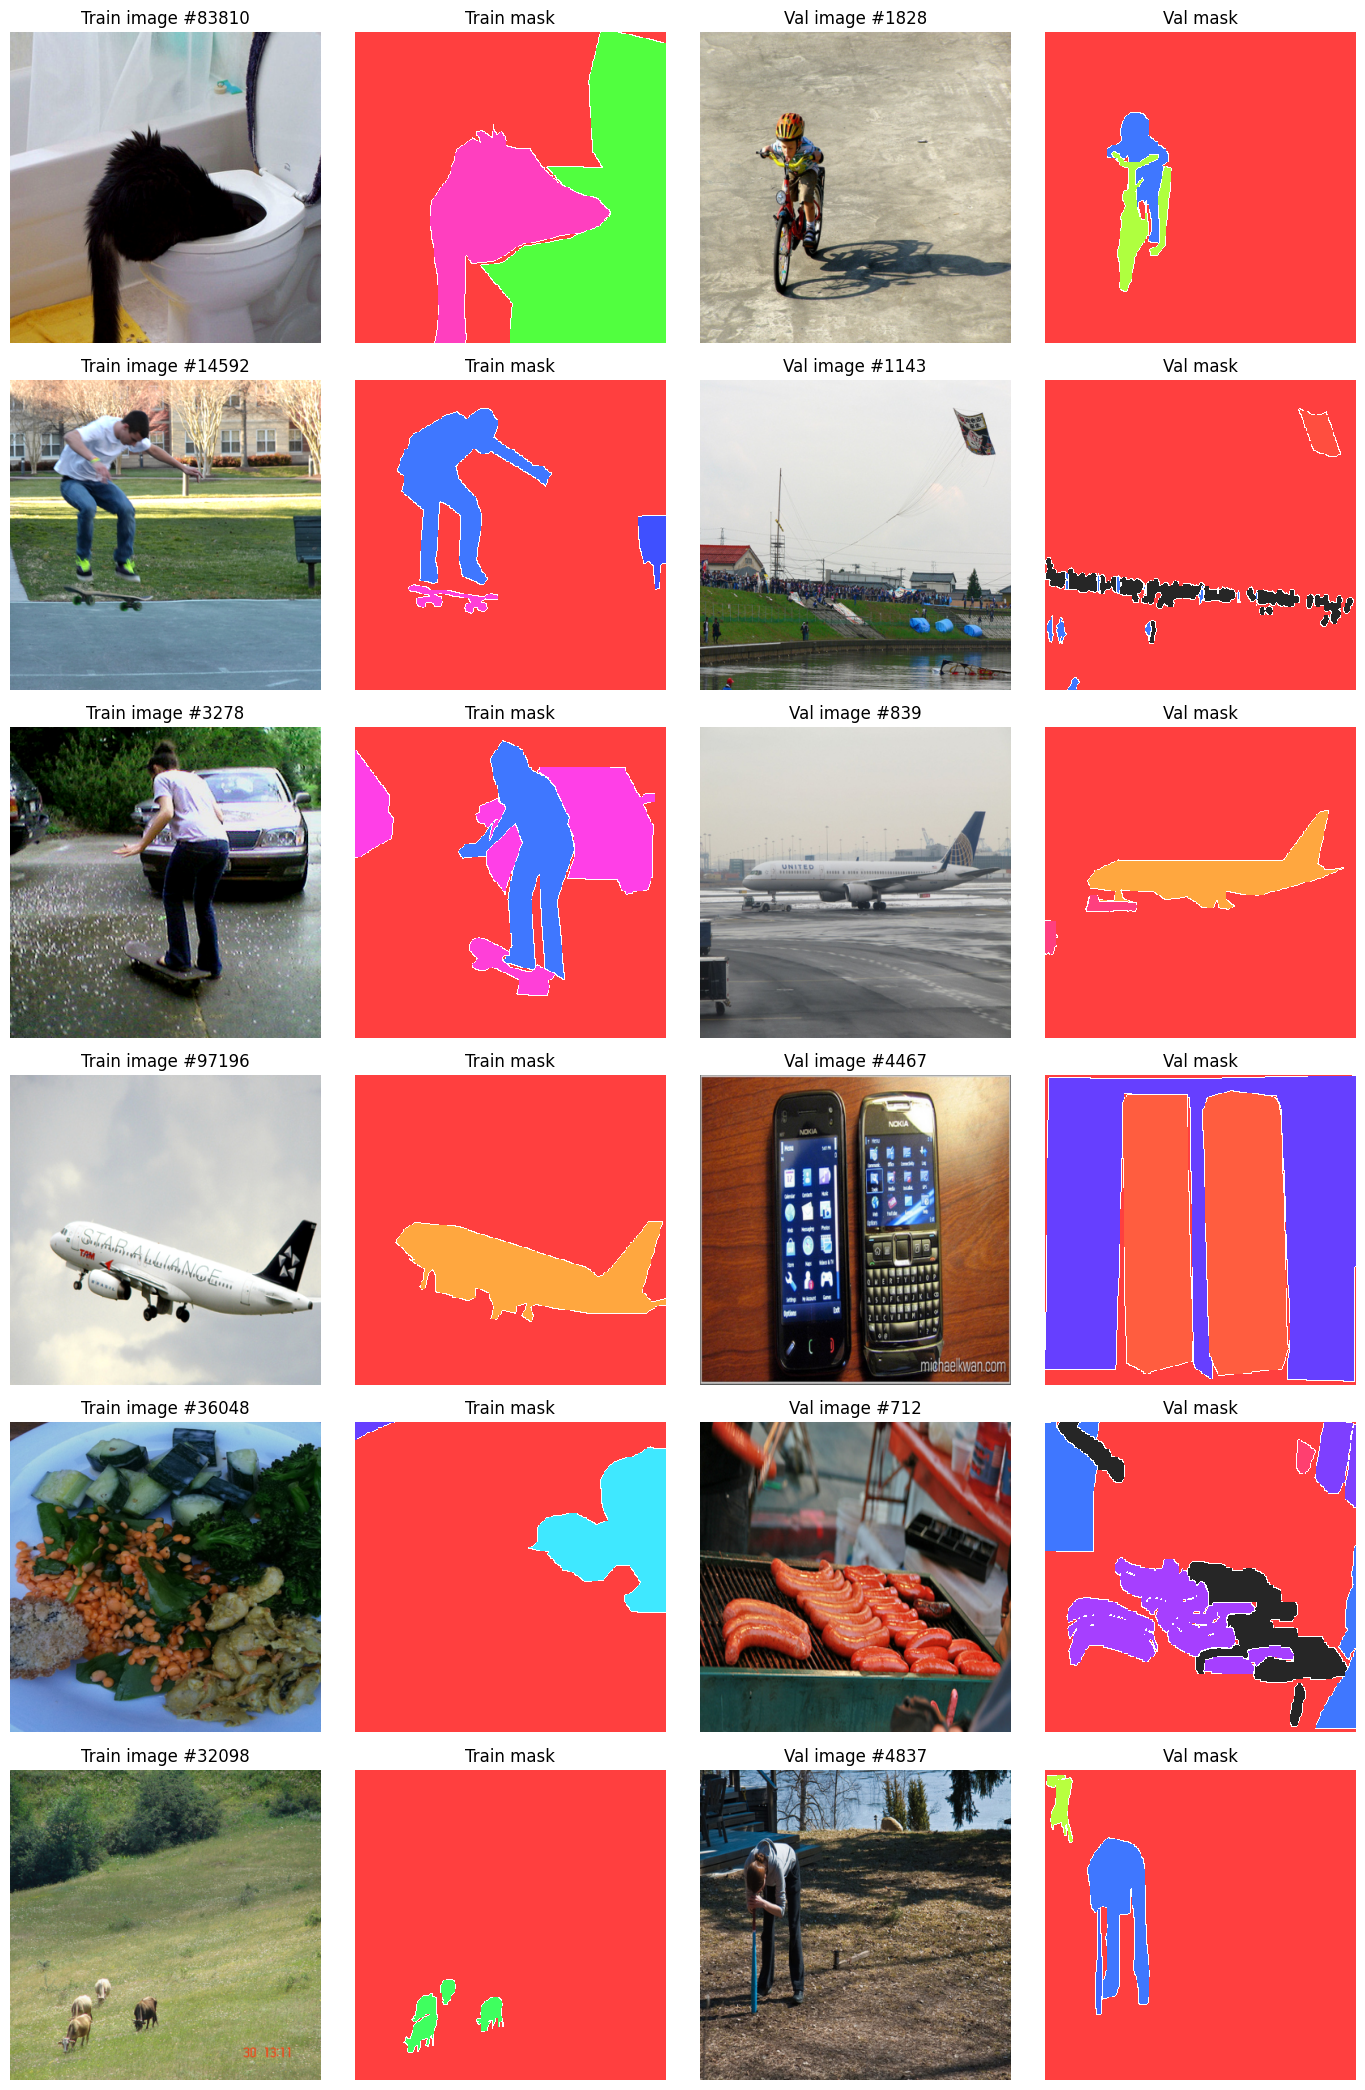

In [36]:
show_train_val_pairs(train_ds, val_ds, n_pairs=6, seed=SEED, ignore_index=IGNORE_INDEX)

### 1.2 Формирование модели и train-loop

In [37]:
# smp.encoders.get_encoder_names()
# smp.encoders.encoders

In [38]:
model = smp.Unet(
    encoder_name="resnet101",
    encoder_weights="imagenet",
    in_channels=3,
    classes=NUM_CLASSES,
    activation=None,
).to(DEVICE)

In [39]:
@torch.no_grad()
def _update_confmat(confmat, logits, target, num_classes=NUM_CLASSES, ignore_index=IGNORE_INDEX):
    # logits: [B, C, H, W], target: [B, H, W]
    pred = logits.argmax(dim=1)
    valid = target != ignore_index
    pred = pred[valid]
    target = target[valid]
    if target.numel() == 0:
        return confmat

    idx = target * num_classes + pred
    binc = torch.bincount(idx, minlength=num_classes * num_classes)
    confmat += binc.reshape(num_classes, num_classes)
    return confmat


@torch.no_grad()
def _miou_from_confmat(confmat):
    # IoU_c = TP / (TP + FP + FN)
    tp = confmat.diag()
    fp = confmat.sum(dim=0) - tp
    fn = confmat.sum(dim=1) - tp
    denom = tp + fp + fn
    iou = tp.float() / torch.clamp(denom.float(), min=1.0)
    return iou.mean().item(), iou.cpu()


In [ ]:
def train_one_epoch(
    model,
    loader,
    optimizer,
    criterion,
    scaler,
    device,
    num_classes=NUM_CLASSES,
    ignore_index=IGNORE_INDEX,
    max_bad_batches=5,
    grad_clip=1.0,
    epoch_idx=None,
    ):
    model.train()
    processed_samples = 0
    bad_batches = 0

    confmat = torch.zeros((num_classes, num_classes), device=device, dtype=torch.int64)

    use_cuda_amp = USE_AMP and str(device).startswith("cuda")
    amp_dtype = (
        torch.bfloat16
        if use_cuda_amp and torch.cuda.is_bf16_supported()
        else torch.float16
    )

    running_loss_sum = torch.zeros((), device=device)

    for bidx, (images, masks) in enumerate(tqdm(loader, mininterval=2.0)):
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        if masks.dtype != torch.long:
            masks = masks.long()
            print("bidx=", bidx, " masks.dtype != torch.long:")
        
        # батч целиком ignore может получиться из-за crop. loss может стать nan/inf — пропускаем
        valid = masks != ignore_index
        if not valid.any():
            continue

        # Проверка на лишние лишние классы
        # t = masks[valid]
        # t_min = int(t.min().item())
        # t_max = int(t.max().item())
        # if t_min < 0 or t_max >= num_classes:
        #     bad_batches += 1
        #     print(
        #         f"[bad-target] epoch={epoch_idx} batch={bidx} "
        #         f"min={t_min} max={t_max} num_classes={num_classes}"
        #     )
        #     if bad_batches >= max_bad_batches:
        #         raise RuntimeError("Too many bad batches: invalid targets")
        #     continue

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast('cuda', dtype=amp_dtype , enabled=use_cuda_amp):
            logits = model(images)

            # if not torch.isfinite(logits).all():
            #     bad_batches += 1
            #     print(f"[bad-logits] epoch={epoch_idx} batch={bidx}")
            #     if bad_batches >= max_bad_batches:
            #         raise RuntimeError("Too many bad batches: non-finite logits")
            #     continue

            loss = criterion(logits, masks)
        
        if not torch.isfinite(loss):
            bad_batches += 1
            print(f"[bad-loss] epoch={epoch_idx} batch={bidx} loss={loss.detach().item()}")
            if bad_batches >= max_bad_batches:
                raise RuntimeError("Too many bad batches: non-finite loss")
            continue

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)

        grad_norm = torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=grad_clip,
            error_if_nonfinite=False,
        )
        if not torch.isfinite(grad_norm):
            bad_batches += 1
            print(f"[bad-grad] epoch={epoch_idx} batch={bidx} grad_norm={float(grad_norm)}")
            optimizer.zero_grad(set_to_none=True)
            if bad_batches >= max_bad_batches:
                raise RuntimeError("Too many bad batches: non-finite gradients")
            continue

        scaler.step(optimizer)
        scaler.update()

        bs = images.size(0)
        running_loss_sum += loss.detach() * bs
        processed_samples += bs
        _update_confmat(confmat, logits, masks, num_classes, ignore_index)
    
    if processed_samples == 0:
        raise RuntimeError(f"All batches skipped in epoch={epoch_idx}")

    epoch_loss = (running_loss_sum / processed_samples).item()
    epoch_miou, _ = _miou_from_confmat(confmat)

    if bad_batches > 0:
        print(f"[warn] epoch={epoch_idx} bad_batches={bad_batches}")

    return epoch_loss, epoch_miou

@torch.no_grad()
def evaluate(model, loader, criterion, device, num_classes=NUM_CLASSES, ignore_index=IGNORE_INDEX):
    model.eval()

    confmat = torch.zeros((num_classes, num_classes), device=device, dtype=torch.int64)
    running_loss_sum = torch.zeros((), device=device)
    processed_samples = 0

    # use_cuda_amp = USE_AMP and str(device).startswith("cuda")
    # amp_dtype = (
    #     torch.bfloat16
    #     if use_cuda_amp and torch.cuda.is_bf16_supported()
    #     else torch.float16
    # )

    # for bidx, (images, masks) in enumerate(loader):
    for bidx, (images, masks) in enumerate(tqdm(loader, mininterval=2.0)):
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True).long()

        # with torch.amp.autocast("cuda", dtype=amp_dtype, enabled=use_cuda_amp):
        #     logits = model(images)
        #     loss = criterion(logits, masks)
        
        logits = model(images)

        valid = masks != ignore_index
        if not valid.any():
            continue

        t = masks[valid]
        t_min = int(t.min().item())
        t_max = int(t.max().item())
        if t_min < 0 or t_max >= num_classes:
            raise RuntimeError(f"[eval bad-target] batch={bidx} min={t_min} max={t_max}")

        loss = criterion(logits, masks)
        if not torch.isfinite(loss):
            raise RuntimeError(f"[eval bad-loss] batch={bidx} loss={loss.detach().item()}")

        bs = images.size(0)
        running_loss_sum += loss.detach() * bs
        processed_samples += bs
        _update_confmat(confmat, logits, masks, num_classes, ignore_index)

    if processed_samples == 0:
        raise RuntimeError("All eval batches skipped")

    epoch_loss = (running_loss_sum / processed_samples).item()
    epoch_miou, class_iou = _miou_from_confmat(confmat)
    return epoch_loss, epoch_miou, class_iou

In [41]:
def save_topk_checkpoint(
    model,
    epoch,
    train_miou,
    val_miou,
    history,
    optimizer=None,
    scheduler=None,
    scaler=None,
    ckpt_dir=CKPT_TOPK_DIR,
    top_k=3,
    heap_state=None,
):
    os.makedirs(ckpt_dir, exist_ok=True)
    if heap_state is None:
        heap_state = []  # (val_miou, path)

    ckpt_path = os.path.join(
        ckpt_dir, f"epoch_{epoch:03d}_val_{val_miou:.4f}_train_{train_miou:.4f}.pt"
    )

    payload = {
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict() if optimizer is not None else None,
        "scheduler_state_dict": scheduler.state_dict() if scheduler is not None else None,
        "scaler_state_dict": scaler.state_dict() if scaler is not None else None,
        "train_miou": float(train_miou),
        "val_miou": float(val_miou),
        "history": history,
    }

    if len(heap_state) < top_k:
        torch.save(payload, ckpt_path)
        heapq.heappush(heap_state, (val_miou, ckpt_path))
    else:
        worst_miou, worst_path = heap_state[0]
        if val_miou > worst_miou:
            heapq.heapreplace(heap_state, (val_miou, ckpt_path))
            if os.path.exists(worst_path):
                os.remove(worst_path)
            torch.save(payload, ckpt_path)

    return heap_state

In [42]:
def learning_loop(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    epochs,
    device,
    scaler=None,
    scheduler=None,
    num_classes=NUM_CLASSES,
    ignore_index=IGNORE_INDEX,
    verbose=True,
    plot_live=True,
):
    """Полный цикл обучения + валидация + live-графики + best checkpoint."""

    if scaler is None:
        scaler = torch.amp.GradScaler('cuda', enabled=USE_AMP)

    history = {
        "train_loss": [],
        "train_miou": [],
        "val_loss": [],
        "val_miou": [],
        "lr": [],
    }
    
    best_val_miou = -1.0
    best_state = copy.deepcopy(model.state_dict())

    def _plot_history():
        ep = range(1, len(history["train_loss"]) + 1)
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))

        axes[0].plot(ep, history["train_loss"], label="train")
        axes[0].plot(ep, history["val_loss"], label="val")
        axes[0].set_title("Loss")
        axes[0].set_xlabel("Epoch")
        axes[0].grid(True, alpha=0.3)
        axes[0].legend()

        axes[1].plot(ep, history["train_miou"], label="train")
        axes[1].plot(ep, history["val_miou"], label="val")
        axes[1].set_title("mIoU")
        axes[1].set_xlabel("Epoch")
        axes[1].grid(True, alpha=0.3)
        axes[1].legend()

        axes[2].plot(ep, history["lr"], label="lr")
        axes[2].set_title("Learning Rate")
        axes[2].set_xlabel("Epoch")
        axes[2].grid(True, alpha=0.3)
        axes[2].legend()

        plt.tight_layout()
        plt.show()

    topk_heap = []

    for epoch in range(1, epochs + 1):
        t0 = time.time()

        train_loss, train_miou = train_one_epoch(
            model=model,
            loader=train_loader,
            optimizer=optimizer,
            criterion=criterion,
            scaler=scaler,
            device=device,
            num_classes=num_classes,
            ignore_index=ignore_index,
            epoch_idx=epoch
        )

        val_loss, val_miou, _ = evaluate(
            model=model,
            loader=val_loader,
            criterion=criterion,
            device=device,
            num_classes=num_classes,
            ignore_index=ignore_index,
        )

        current_lr = optimizer.param_groups[0]["lr"]

        history["train_loss"].append(train_loss)
        history["train_miou"].append(train_miou)
        history["val_loss"].append(val_loss)
        history["val_miou"].append(val_miou)
        history["lr"].append(current_lr)

        if scheduler is not None:
            scheduler.step()

        if val_miou > best_val_miou:
            best_val_miou = val_miou
            best_state = copy.deepcopy(model.state_dict())
        
        topk_heap = save_topk_checkpoint(
            model=model,
            epoch=epoch,
            train_miou=train_miou,
            val_miou=val_miou,
            history=history,
            optimizer=optimizer,
            scheduler=scheduler,
            scaler=scaler,
            ckpt_dir=CKPT_TOPK_DIR,
            top_k=10,
            heap_state=topk_heap,
        )

        if verbose:
            dt = time.time() - t0
            print(
                f"Epoch {epoch:02d}/{epochs} | "
                f"train_loss={train_loss:.4f} train_mIoU={train_miou:.4f} | "
                f"val_loss={val_loss:.4f} val_mIoU={val_miou:.4f} | "
                f"lr={current_lr:.2e} | time={dt:.1f}s"
            )

        if plot_live:
            clear_output(wait=True)
            _plot_history()

    model.load_state_dict(best_state)

    if not plot_live:
        _plot_history()

    return model, history, best_val_miou, topk_heap


### 1.3 Обучение модели

Этапы обучения:
1. С замороженным энкодером
<!-- 2. С полностью размороженными весами и уменьшенным lr -->

In [43]:
for p in model.encoder.parameters():
    p.requires_grad = False

Проверим, что веса заморожены

In [44]:
def beautiful_int(i):
    i = str(i)
    return ".".join(reversed([i[max(j, 0):j+3] for j in range(len(i) - 3, -3, -3)]))

# Считаем общее число параметров в нашей модели
def model_num_params(model, verbose_all=True, verbose_only_learnable=False):
    sum_params = 0
    sum_learnable_params = 0
    submodules = defaultdict(lambda : [0, 0])
    for name, param in model.named_parameters():
        num_params = np.prod(param.shape)
        if verbose_all or (verbose_only_learnable and param[1].requires_grad):
            print(
                colored(
                    '{: <42} ~  {: <9} params ~ grad: {}'.format(
                        name,
                        beautiful_int(num_params),
                        param.requires_grad,
                    ),
                    {True: "green", False: "red"}[param[1].requires_grad],
                )
            )
        sum_params += num_params
        sm = name.split(".")[0]
        submodules[sm][0] += num_params
        if param.requires_grad:
            sum_learnable_params += num_params
            submodules[sm][1] += num_params
    print(
        f'\nIn total:\n  - {beautiful_int(sum_params)} params\n  - {beautiful_int(sum_learnable_params)} learnable params'
    )
    
    for sm, v in submodules.items():
        print(
            f"\n . {sm}:\n .   - {beautiful_int(submodules[sm][0])} params\n .   - {beautiful_int(submodules[sm][1])} learnable params"
        )
    return sum_params, sum_learnable_params


sum_params, sum_learnable_params = model_num_params(model)

encoder.conv1.weight                       ~  9.408     params ~ grad: False
encoder.bn1.weight                         ~  64        params ~ grad: False
encoder.bn1.bias                           ~  64        params ~ grad: False
encoder.layer1.0.conv1.weight              ~  4.096     params ~ grad: False
encoder.layer1.0.bn1.weight                ~  64        params ~ grad: False
encoder.layer1.0.bn1.bias                  ~  64        params ~ grad: False
encoder.layer1.0.conv2.weight              ~  36.864    params ~ grad: False
encoder.layer1.0.bn2.weight                ~  64        params ~ grad: False
encoder.layer1.0.bn2.bias                  ~  64        params ~ grad: False
encoder.layer1.0.conv3.weight              ~  16.384    params ~ grad: False
encoder.layer1.0.bn3.weight                ~  256       params ~ grad: False
encoder.layer1.0.bn3.bias                  ~  256       params ~ grad: False
encoder.layer1.0.downsample.0.weight       ~  16.384    params ~ grad: False

Собственно цикл обучения

In [45]:
criterion = torch.nn.CrossEntropyLoss(ignore_index=IGNORE_INDEX)

optimizer = torch.optim.AdamW(
    (p for p in model.parameters() if p.requires_grad),
    lr=LR,
    weight_decay=WEIGHT_DECAY,
)

scheduler = torch.optim.lr_scheduler.SequentialLR(
    optimizer,
    schedulers=[
        torch.optim.lr_scheduler.ConstantLR(
            optimizer,
            factor=1.0,
            total_iters=WARM_EPOCHS,
        ),
        torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer,
            T_max=EPOCHS - WARM_EPOCHS,
            eta_min=1e-5,
        ),
    ],
    milestones=[WARM_EPOCHS],
)

scaler = torch.amp.GradScaler('cuda', enabled=USE_AMP)

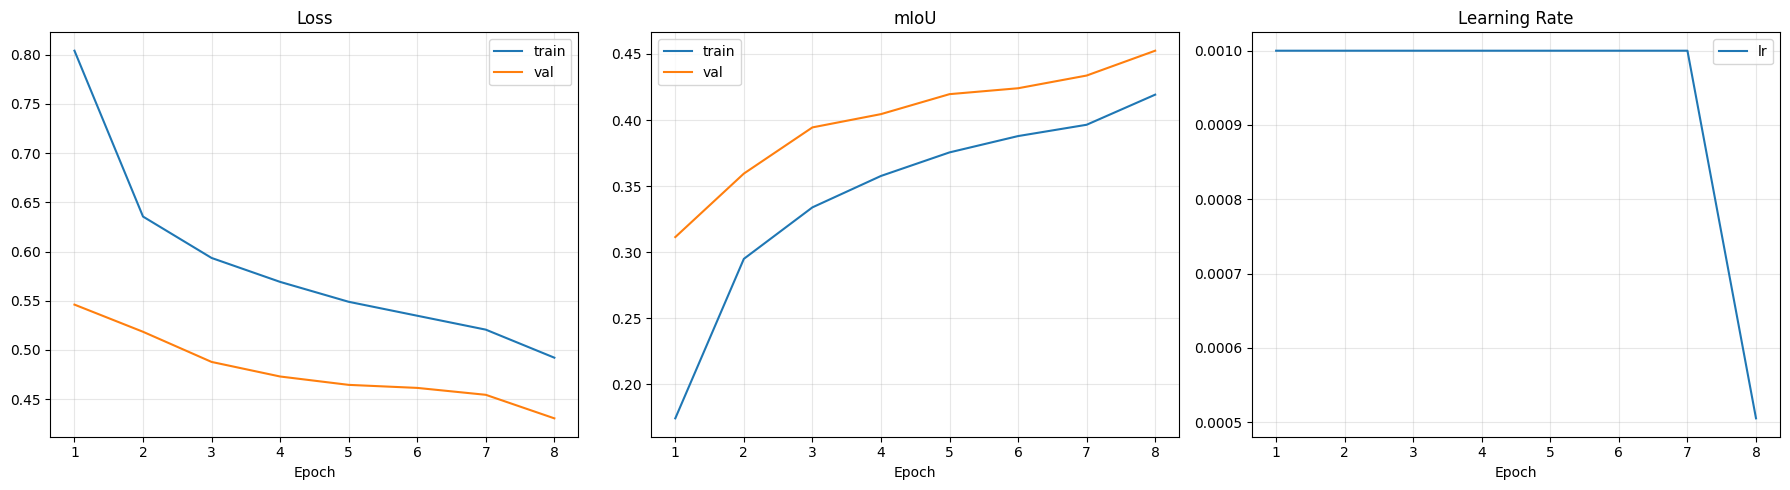

In [46]:
model, history, best_val_miou, topk_heap = learning_loop(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    criterion=criterion,
    epochs=EPOCHS,
    device=DEVICE,
    scaler=scaler,
    scheduler=scheduler,
    num_classes=NUM_CLASSES,
    ignore_index=IGNORE_INDEX,
)

In [47]:
print("Best val mIoU:", round(best_val_miou, 4))

Best val mIoU: 0.4524


### 1.4 Сохранение лучшей модели в fp16

Загрузим лучшую модель

In [48]:
# 1) найти лучший чекпоинт по val_miou
best_path = None
best_val = -1.0

for fname in os.listdir(CKPT_TOPK_DIR):
    if not fname.endswith(".pt"):
        continue
    path = os.path.join(CKPT_TOPK_DIR, fname)
    payload = torch.load(path, map_location="cpu")
    v = float(payload["val_miou"])
    if v > best_val:
        best_val = v
        best_path = path

print("Best checkpoint:", best_path, "val_miou:", best_val)

Best checkpoint: ./weights/topk/epoch_008_val_0.4524_train_0.4192.pt val_miou: 0.4524385333061218


In [49]:
# 2) создать модель той же архитектуры
model = smp.Unet(
    encoder_name="resnet101",
    encoder_weights=None,
    in_channels=3,
    classes=NUM_CLASSES,
    activation=None,
).to(DEVICE)


In [50]:
# 3) загрузить веса
payload = torch.load(best_path, map_location="cpu")
model.load_state_dict(payload["model_state_dict"], strict=True)

# if payload.get("optimizer_state_dict") is not None:
#     optimizer.load_state_dict(payload["optimizer_state_dict"])
# if scheduler is not None and payload.get("scheduler_state_dict") is not None:
#     scheduler.load_state_dict(payload["scheduler_state_dict"])
# if scaler is not None and payload.get("scaler_state_dict") is not None:
#     scaler.load_state_dict(payload["scaler_state_dict"])
# start_epoch = payload["epoch"] + 1
# history = payload.get("history", None)

model.eval()

Unet(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
      

Переведем модель в fp16 и сохраним

In [51]:
model_fp16 = copy.deepcopy(model).half().to(DEVICE).eval()
torch.save(model_fp16.state_dict(), CKPT_DIR + "checkpoint_coco_fp16.pt")

### 1.4 Получение метрик baseline

In [52]:
@torch.no_grad()
def per_class_iou(
    model,
    loader,
    device,
    class_names,
    num_classes=NUM_CLASSES,
    ignore_index=IGNORE_INDEX,
    ):
    model.eval()
    confmat = torch.zeros((num_classes, num_classes), dtype=torch.int64, device=device)

    param_dtype = next(model.parameters()).dtype

    for images, masks in loader:
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True).long()

        if param_dtype in (torch.float16, torch.bfloat16):
            images = images.to(dtype=param_dtype)
        # if is_half_model:
        #     images = images.half()

        logits = model(images)
        preds = logits.argmax(dim=1)

        valid = masks != ignore_index
        t = masks[valid]
        p = preds[valid]
        if t.numel() == 0:
            continue

        idx = t * num_classes + p
        confmat += torch.bincount(idx, minlength=num_classes**2).reshape(num_classes, num_classes)

    tp = confmat.diag()
    fp = confmat.sum(0) - tp
    fn = confmat.sum(1) - tp
    denom = tp + fp + fn

    iou = tp.float() / torch.clamp(denom.float(), min=1.0)
    present = denom > 0
    miou_present = iou[present].mean().item()

    rows = []
    for i in range(num_classes):
        rows.append({
            "class_id": i,
            "class_name": class_names[i],
            "iou": float(iou[i].item()),
            "present_in_val": bool(present[i].item()),
            "pixels_gt_or_pred": int(denom[i].item()),
        })

    return rows, miou_present

In [53]:
def compare_fp32_fp16_per_class_iou(
    model,
    model_fp16,
    loader,
    device,
    class_names,
    per_class_iou_fn,
    num_classes=NUM_CLASSES,
    ignore_index=IGNORE_INDEX,
    max_classes_on_plot=None,  # например 30, чтобы график не был перегружен
):
    """
    Считает per-class IoU и mIoU для model (fp32) и model_fp16, строит сравнительную гистограмму.

    Args:
        model: fp32 модель
        model_fp16: fp16 модель
        loader: val_loader
        device: 'cuda' / 'cpu'
        class_names: список названий классов длины num_classes
        per_class_iou_fn: твоя функция per_class_iou(model, loader, device, num_classes, ignore_index)
        num_classes: число классов
        ignore_index: ignore index
        max_classes_on_plot: ограничение числа классов на графике (None = все)
    Returns:
        dict с метриками и таблицей по классам
    """
    rows_fp32, miou_fp32 = per_class_iou_fn(
        model, loader, device, class_names, num_classes=num_classes, ignore_index=ignore_index
    )
    rows_fp16, miou_fp16 = per_class_iou_fn(
        model_fp16, loader, device, class_names, num_classes=num_classes, ignore_index=ignore_index
    )

    iou_fp32 = np.array([r["iou"] for r in rows_fp32], dtype=np.float32)
    iou_fp16 = np.array([r["iou"] for r in rows_fp16], dtype=np.float32)
    delta = iou_fp16 - iou_fp32

    idx = np.arange(num_classes)
    if max_classes_on_plot is not None and max_classes_on_plot < num_classes:
        # показываем классы с наибольшей разницей
        chosen = np.argsort(np.abs(delta))[::-1][:max_classes_on_plot]
        chosen = np.sort(chosen)
        idx = chosen

    width = 0.42
    x = np.arange(len(idx))

    plt.figure(figsize=(max(12, len(idx) * 0.35), 6))
    plt.bar(x - width / 2, iou_fp32[idx], width=width, label="model (fp32)")
    plt.bar(x + width / 2, iou_fp16[idx], width=width, label="model_fp16 (fp16)")
    plt.xticks(x, [class_names[i] for i in idx], rotation=90)
    plt.ylabel("IoU")
    plt.title(
        f"Per-class IoU: fp32 vs fp16 | mIoU fp32={miou_fp32:.4f}, fp16={miou_fp16:.4f}, Δ={miou_fp16 - miou_fp32:+.4f}"
    )
    plt.grid(axis="y", alpha=0.25)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return {
        "miou_fp32": float(miou_fp32),
        "miou_fp16": float(miou_fp16),
        "miou_delta_fp16_minus_fp32": float(miou_fp16 - miou_fp32),
        "rows_fp32": rows_fp32,
        "rows_fp16": rows_fp16,
    }

In [54]:
rows, miou_present = per_class_iou(model, val_loader, DEVICE, val_ds.class_names, num_classes=NUM_CLASSES, ignore_index=IGNORE_INDEX)
print("mIoU (only present classes):", round(miou_present, 4))

for r in rows:
    print(f"{r['class_id']:2d} {r['class_name']:12s} IoU={r['iou']:.3f} present={r['present_in_val']}")


mIoU (only present classes): 0.4524
 0 background   IoU=0.874 present=True
 1 person       IoU=0.769 present=True
 2 bicycle      IoU=0.516 present=True
 3 car          IoU=0.451 present=True
 4 motorcycle   IoU=0.681 present=True
 5 airplane     IoU=0.639 present=True
 6 bus          IoU=0.639 present=True
 7 train        IoU=0.635 present=True
 8 truck        IoU=0.376 present=True
 9 boat         IoU=0.420 present=True
10 traffic light IoU=0.488 present=True
11 fire hydrant IoU=0.738 present=True
12 stop sign    IoU=0.823 present=True
13 parking meter IoU=0.641 present=True
14 bench        IoU=0.336 present=True
15 bird         IoU=0.689 present=True
16 cat          IoU=0.766 present=True
17 dog          IoU=0.664 present=True
18 horse        IoU=0.609 present=True
19 sheep        IoU=0.643 present=True
20 cow          IoU=0.607 present=True
21 elephant     IoU=0.814 present=True
22 bear         IoU=0.808 present=True
23 zebra        IoU=0.864 present=True
24 giraffe      IoU=0.773 

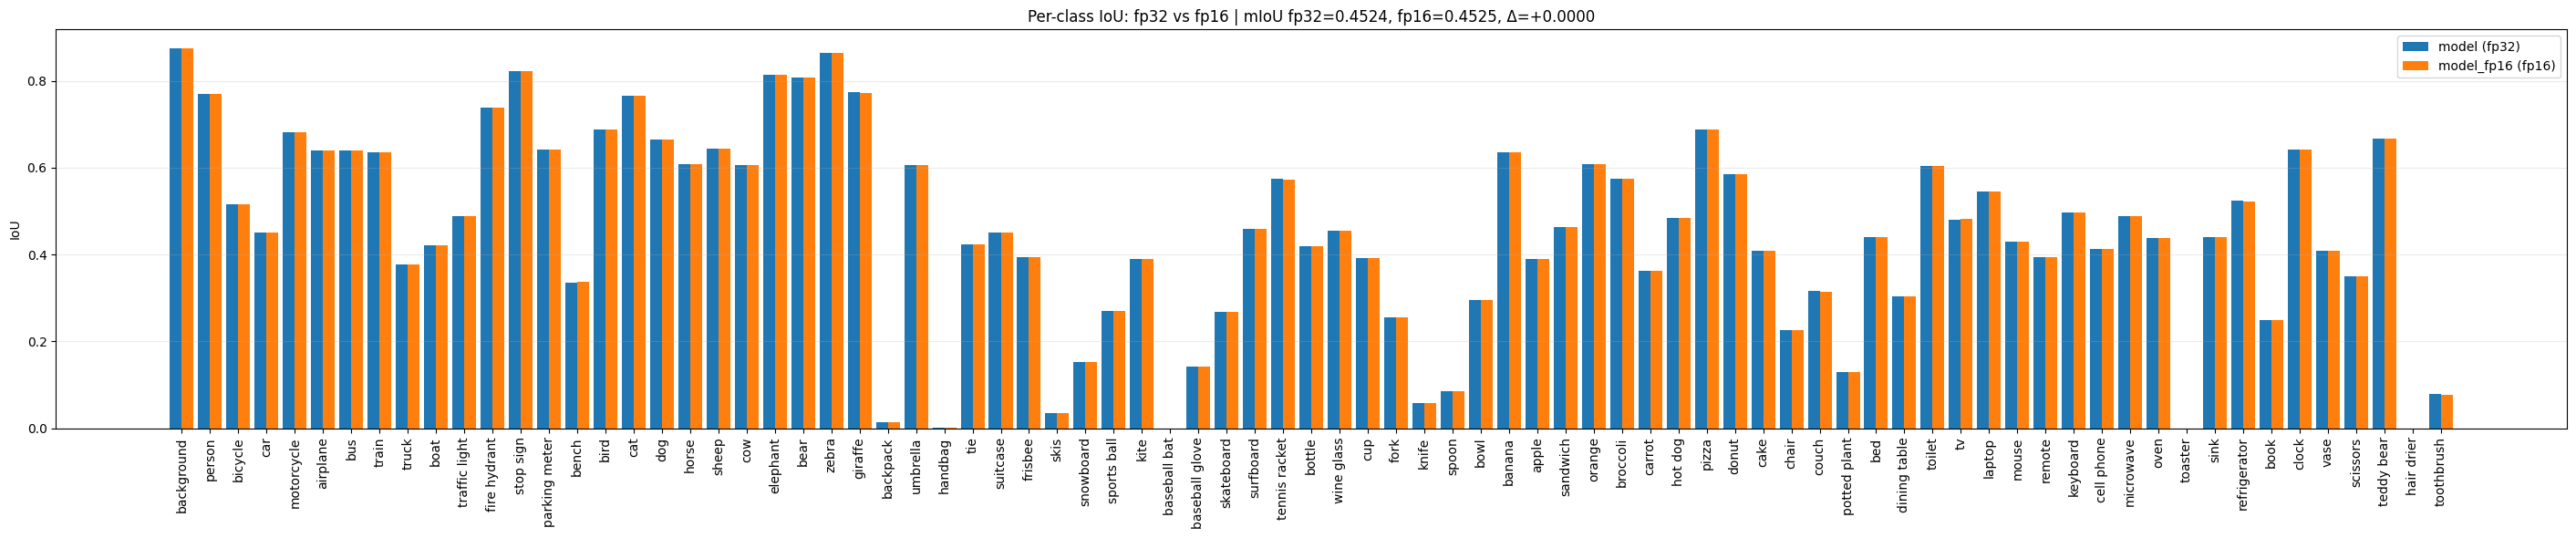

In [55]:
result = compare_fp32_fp16_per_class_iou(
    model=model,
    model_fp16=model_fp16,
    loader=val_loader,
    device=DEVICE,
    class_names=val_ds.class_names,
    per_class_iou_fn=per_class_iou,
    num_classes=NUM_CLASSES,
    ignore_index=IGNORE_INDEX,
    max_classes_on_plot=None,
)

In [56]:
print(result["miou_fp32"], result["miou_fp16"], result["miou_delta_fp16_minus_fp32"])

0.4524385333061218 0.45245295763015747 1.4424324035644531e-05


Визуализация предсказаний

In [61]:
def show_val_predictions_triplets(
    model,
    val_ds,
    device,
    n_samples: int = 4,
    seed: int = 47,
    ignore_index: int = IGNORE_INDEX,
    max_legend_classes: int = 10,
):
    model.eval()
    rng = random.Random(seed)
    idxs = [rng.randrange(len(val_ds)) for _ in range(n_samples)]

    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)

    num_classes = val_ds.num_classes
    ignore_show_id = num_classes
    cmap, norm = _build_seg_cmap_with_ignore(num_classes)

    fig, axes = plt.subplots(
        n_samples, 4, figsize=(16, 4 * n_samples),
        gridspec_kw={"width_ratios": [1, 1, 1, 0.9]}
    )
    if n_samples == 1:
        axes = np.expand_dims(axes, axis=0)

    param_dtype = next(model.parameters()).dtype

    with torch.no_grad():
        for i, idx in enumerate(idxs):
            image, true_mask = val_ds[idx]
            x = image.unsqueeze(0).to(device, non_blocking=True)

            if param_dtype in (torch.float16, torch.bfloat16):
                x = x.to(dtype=param_dtype)

            logits = model(x)
            pred_mask = logits.argmax(dim=1).squeeze(0).cpu().numpy()

            img_show = (image.cpu() * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()
            true_show = true_mask.cpu().numpy().copy()
            true_show[true_show == ignore_index] = ignore_show_id

            axes[i, 0].imshow(img_show)
            axes[i, 0].set_title(f"image #{idx}")
            axes[i, 0].axis("off")

            axes[i, 1].imshow(true_show, cmap=cmap, norm=norm, interpolation="nearest")
            axes[i, 1].imshow(_boundary_rgba(true_show), interpolation="nearest")
            axes[i, 1].set_title("true_mask_val")
            axes[i, 1].axis("off")

            axes[i, 2].imshow(pred_mask, cmap=cmap, norm=norm, interpolation="nearest")
            axes[i, 2].imshow(_boundary_rgba(pred_mask), interpolation="nearest")
            axes[i, 2].set_title("pred_mask")
            axes[i, 2].axis("off")

            # Легенда только по классам этой тройки
            ids, counts = np.unique(np.concatenate([true_show.ravel(), pred_mask.ravel()]), return_counts=True)
            order = np.argsort(-counts)
            ids = ids[order]

            shown = ids[:max_legend_classes]
            handles = []
            for cid in shown:
                cid = int(cid)
                if cid == ignore_show_id:
                    label = "255: ignore"
                else:
                    label = f"{cid}: {val_ds.class_names[cid]}"
                handles.append(Patch(facecolor=cmap(cid), edgecolor="none", label=label))                

            axes[i, 3].axis("off")
            axes[i, 3].legend(handles=handles, loc="upper left", frameon=False, fontsize=8, handlelength=1.0)
            extra = len(ids) - len(shown)
            axes[i, 3].set_title(f"classes in sample{f' (+{extra} more)' if extra > 0 else ''}", fontsize=9)

    plt.tight_layout()
    plt.show()

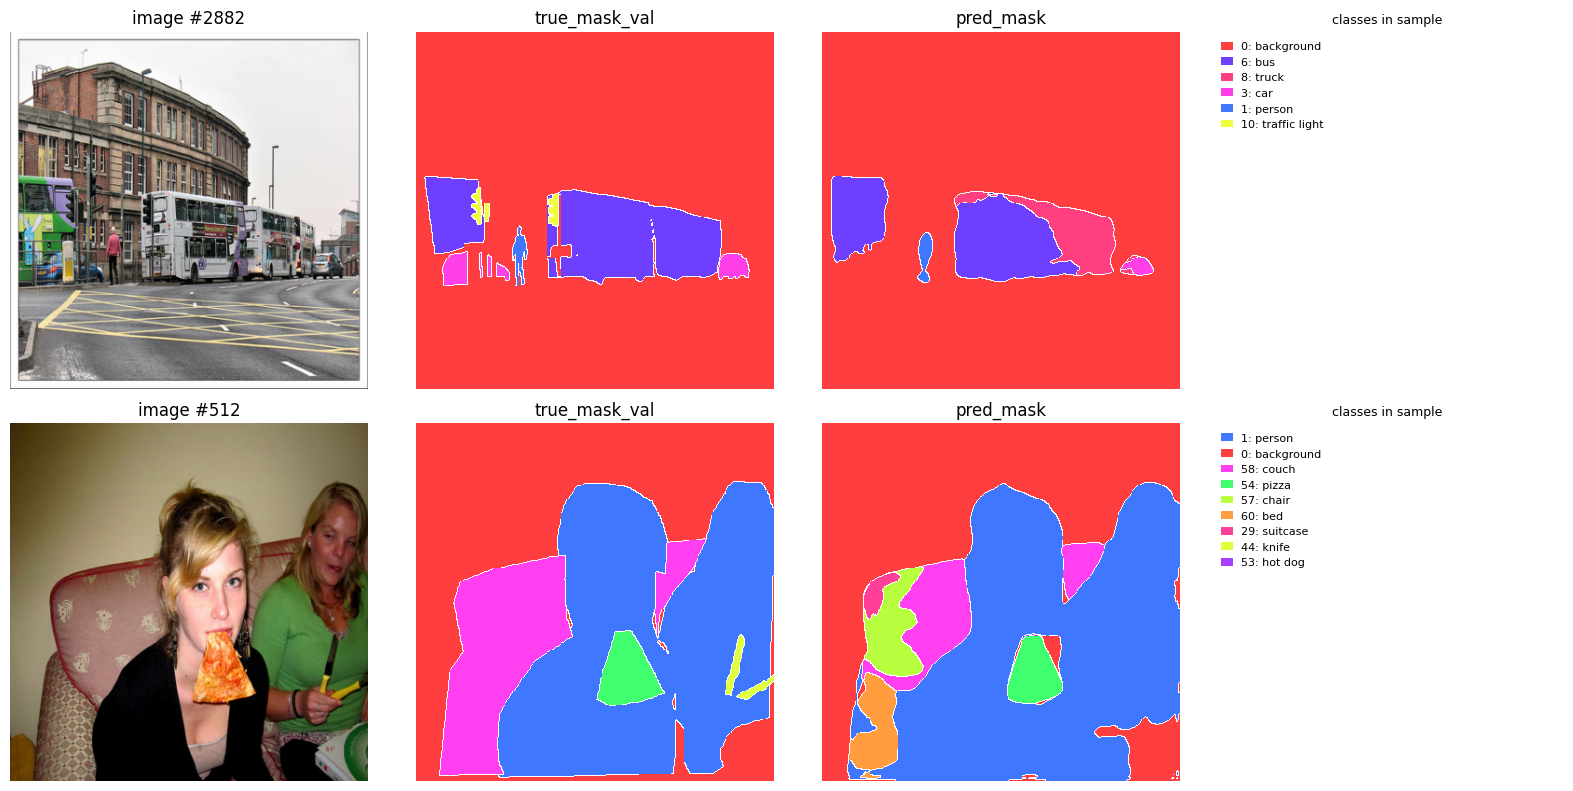

In [62]:
show_val_predictions_triplets(
    model=model,
    val_ds=val_ds,
    device=DEVICE,
    n_samples=2,
    ignore_index=IGNORE_INDEX,
)